# LeetCode #66: Plus One

https://leetcode.com/problems/plus-one/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(n)$ |
| **Carry Simulation** ★ | $O(n)$ | $O(1)$* |

*$O(n)$ only in the all-9s case when a new leading digit must be allocated.

---

## Understanding the Methods

### Brute Force
Convert the digit array to an integer, add 1, then convert back to an array. Simple but requires an intermediate integer that can overflow for large inputs and always allocates a fresh array.

### Optimal: Carry Simulation ★
Scan right-to-left. If a digit is less than 9, increment it and return immediately — no carry propagates. If it is 9, set it to 0 and continue left. If the entire array was 9s, allocate one new array of size n+1 with a leading 1.

**Why this is better than Brute Force:** Short-circuits the moment a digit absorbs the +1, so most inputs take $O(1)$ work. Avoids integer conversion and handles arbitrarily large arrays without overflow risk.

**Constraints:**
* 1 ≤ digits.length ≤ 100
* 0 ≤ digits[i] ≤ 9
* No leading zeros (except the number 0 itself)

## Solutions

### C#

In [ ]:
public class Solution {
    public int[] PlusOne(int[] digits) {
        for (int i = digits.Length - 1; i >= 0; i--) {
            // Digit absorbs the +1 — no carry propagates further
            if (digits[i] < 9) {
                digits[i]++;
                return digits;
            }
            digits[i] = 0;
        }
        // All digits were 9 — need a new leading 1
        int[] result = new int[digits.Length + 1];
        result[0] = 1;
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def plusOne(self, digits: List[int]) -> List[int]:
        for i in range(len(digits) - 1, -1, -1):
            # Digit absorbs the +1 — no carry propagates further
            if digits[i] < 9:
                digits[i] += 1
                return digits
            digits[i] = 0
        # All digits were 9 — prepend a leading 1
        return [1] + digits

### Go

In [ ]:
func plusOne(digits []int) []int {
    for i := len(digits) - 1; i >= 0; i-- {
        // Digit absorbs the +1 — no carry propagates further
        if digits[i] < 9 {
            digits[i]++
            return digits
        }
        digits[i] = 0
    }
    // All digits were 9 — prepend a leading 1
    return append([]int{1}, digits...)
}

### Rust

In [ ]:
pub fn plus_one(mut digits: Vec<i32>) -> Vec<i32> {
    for i in (0..digits.len()).rev() {
        // Digit absorbs the +1 — no carry propagates further
        if digits[i] < 9 {
            digits[i] += 1;
            return digits;
        }
        digits[i] = 0;
    }
    // All digits were 9 — prepend a leading 1
    digits.insert(0, 1);
    digits
}

## Example Scenarios

**1. Common Case**
**Input:** digits = [1, 2, 3]
i=2: 3 < 9 → digits[2]=4, return immediately. No carry needed. Output: **[1, 2, 4]**.

**2. Slightly Complex — single carry step**
**Input:** digits = [1, 2, 9]
i=2: 9 → set to 0, carry. i=1: 2 < 9 → digits[1]=3, return. Output: **[1, 3, 0]**.

**3. Edge Case: Time Factor — carry propagates the full length**
**Input:** digits = [9, 9, 9, 9]
All four digits are 9: each is set to 0 in turn, loop exits without early return. A new 5-element array [1,0,0,0,0] is allocated. This is the only case that visits all $n$ digits — every other input short-circuits earlier. Output: **[1, 0, 0, 0, 0]**.

**4. Edge Case: Space Factor — all-9s allocates the only extra array**
**Input:** digits = [9, 9, 9]
All non-all-9s inputs reuse the original array in-place ($O(1)$ extra space). Only this path allocates a new array of size $n+1$. The new array [1, 0, 0, 0] is the maximum extra allocation possible. Output: **[1, 0, 0, 0]**.

**5. Almost-Impossible but Plausible — single-digit 9**
**Input:** digits = [9]
i=0: 9 → set to 0, loop exits. The new array [1, 0] is returned. This is the shortest all-9s input and confirms the post-loop path works for length-1 arrays with no out-of-bounds access. Output: **[1, 0]**.

## Infographic

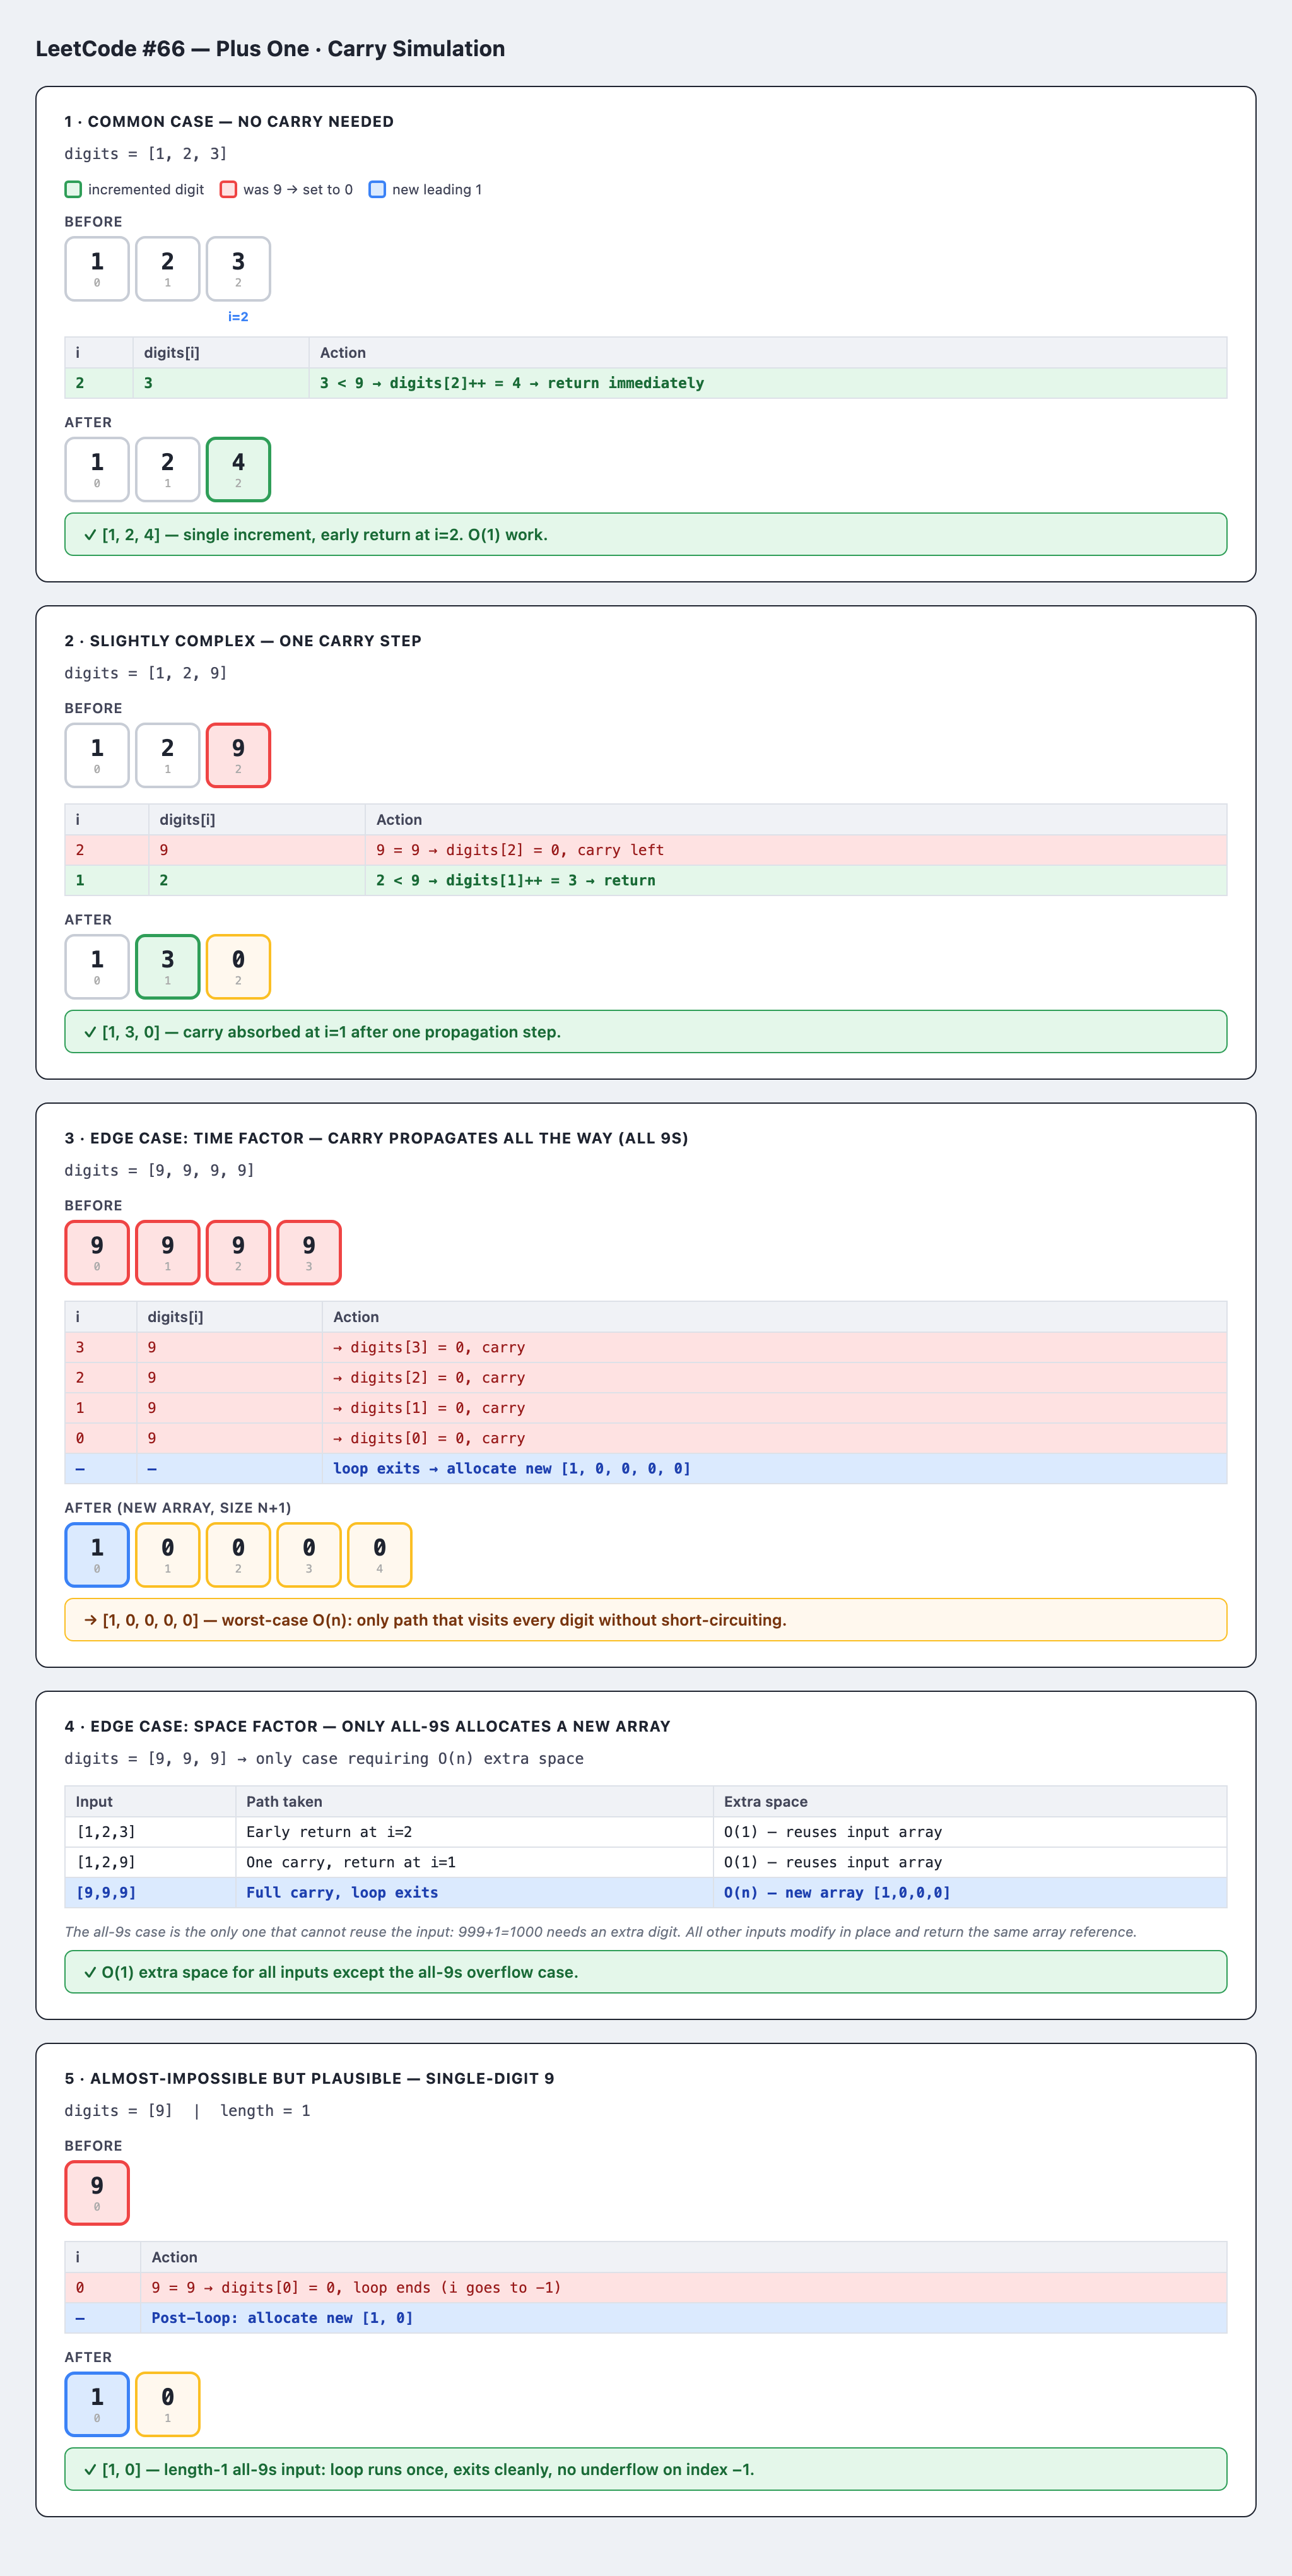